In [1]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
!pip install ultralytics roboflow matplotlib seaborn scikit-learn opencv-python-headless -q
!pip install torch torchvision --quiet  # already in Colab, just ensuring

import os, json, cv2, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

print("✅ Imports done | Device:", "GPU" if torch.cuda.is_available() else "CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 55.4 MB/s eta 0:00:00
✅ Imports done | Device: GPU


In [2]:
# ============================================================
# CELL 2A — Download from Roboflow
# ============================================================
from roboflow import Roboflow

# Sign up free at roboflow.com to get your API key
RF_API_KEY = "SjLEwOlnL2CKaO79Hm6l"
rf = Roboflow(api_key=RF_API_KEY)

# Example: search roboflow.com/universe for "pothole segmentation"
# then replace workspace/project/version below
project = rf.workspace("gp-grakz").project("pothole-segmentation-g6hbh")
dataset = project.version(1).download("yolov8")  # yolov8 format works for yolov11

DATASET_DIR = dataset.location
print("Dataset downloaded to:", DATASET_DIR)

# Verify data.yaml was created
import os
yaml_path = os.path.join(DATASET_DIR, "data.yaml")
print("data.yaml exists:", os.path.exists(yaml_path))

# Print its contents so you can verify class names
with open(yaml_path) as f:
    print("\n--- data.yaml contents ---")
    print(f.read())

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pothole-Segmentation-1 in yolov8:: 100%|██████████| 3262/3262 [00:00<00:00, 5951.34it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/Pothole-Segmentation-1
data.yaml exists: True

--- data.yaml contents ---
names:
- Potholes
nc: 1
roboflow:
  license: CC BY 4.0
  project: pothole-segmentation-g6hbh
  url: https://universe.roboflow.com/gp-grakz/pothole-segmentation-g6hbh/dataset/1
  version: 1
  workspace: gp-grakz
test: ../test/images
train: ../train/images
val: ../valid/images



In [3]:
import os
from google.colab import files

# 1. Upload the kaggle.json file you just downloaded
if not os.path.exists("/content/kaggle.json"):
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# 2. Download and unzip the PothRGBD dataset
# The dataset slug is 'mahyeks/pothrgbd-rgb-and-depth-images-of-potholes'
!kaggle datasets download -d mahyeks/pothrgbd-rgb-and-depth-images-of-potholes
!unzip -q pothrgbd-rgb-and-depth-images-of-potholes.zip -d /content/PothRGBD

# 3. Update your directory paths to point to the new local folder
DATASET_DIR = "/content/PothRGBD"
# Note: Check the exact folder names inside /content/PothRGBD after unzipping
print("Dataset downloaded to:", DATASET_DIR)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes
License(s): MIT
100% 125M/125M [00:01<00:00, 107MB/s] 

Dataset downloaded to: /content/PothRGBD


In [4]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


Is CUDA available? True
GPU Name: Tesla T4


In [5]:
# ============================================================
# CELL 3 (FINAL) — Load both models correctly
# ============================================================
import torch, sys
from pathlib import Path
from ultralytics import YOLO

# --- YOLOv11 ---
YOLO_WEIGHTS = "/content/drive/MyDrive/pothole_project/yolo11_pothole_seg7/weights/best.pt"
yolo_model = YOLO(YOLO_WEIGHTS)
print("YOLOv11 loaded:", yolo_model.info())

# --- Clone DAV2 repo ---
if not Path("/content/Depth-Anything-V2").exists():
    !git clone https://github.com/DepthAnything/Depth-Anything-V2.git /content/Depth-Anything-V2
sys.path.insert(0, "/content/Depth-Anything-V2")
from depth_anything_v2.dpt import DepthAnythingV2 as DAV2

DEPTH_WEIGHTS = "/content/drive/MyDrive/pothole_project/latest_pothole_depth_v2.pth"

# ── Load & auto-detect encoder ──────────────────────────────
raw_ckpt = torch.load(DEPTH_WEIGHTS, map_location='cpu')
state_dict = raw_ckpt.get('model', raw_ckpt.get('state_dict', raw_ckpt))
if any(k.startswith('model.') for k in state_dict.keys()):
    state_dict = {k.replace('model.', '', 1): v for k, v in state_dict.items()}

# Detect from norm weight shape (the unambiguous signal)
hidden_dim = state_dict['pretrained.blocks.0.norm1.weight'].shape[0]
encoder    = {384: 'vits', 768: 'vitb', 1024: 'vitl'}[hidden_dim]
num_blocks = sum(1 for k in state_dict if k.startswith('pretrained.blocks.') and k.endswith('.norm1.weight'))
print(f"✅ Detected: encoder={encoder}, hidden_dim={hidden_dim}, blocks={num_blocks}")

# ── Official DAV2 configs ────────────────────────────────────
CONFIGS = {
    'vits': {'features': 64,  'out_channels': [48,  96,  192,  384]},
    'vitb': {'features': 128, 'out_channels': [96,  192, 384,  768]},
    'vitl': {'features': 256, 'out_channels': [256, 512, 1024, 1024]},
}
cfg = CONFIGS[encoder]
depth_model = DAV2(encoder=encoder, features=cfg['features'], out_channels=cfg['out_channels'])

result = depth_model.load_state_dict(state_dict, strict=False)
print(f"Missing : {len(result.missing_keys)} | Unexpected: {len(result.unexpected_keys)}")
if result.missing_keys:
    print("  Missing:", result.missing_keys[:3])

depth_model = depth_model.cuda().eval()
print(f"\nDepthAnythingV2 ({encoder}) ready ✅")

YOLO11n-seg summary: 204 layers, 2,842,803 parameters, 0 gradients, 9.7 GFLOPs
YOLOv11 loaded: (204, 2842803, 0, 9.726617599999999)
Cloning into '/content/Depth-Anything-V2'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 146 (delta 30), reused 26 (delta 26), pack-reused 86 (from 2)
Receiving objects: 100% (146/146), 45.18 MiB | 22.97 MiB/s, done.
Resolving deltas: 100% (46/46), done.


✅ Detected: encoder=vits, hidden_dim=384, blocks=12
Missing : 0 | Unexpected: 0

DepthAnythingV2 (vits) ready ✅


In [6]:
from pathlib import Path
import os

# 1. Print actual working directory
print(f"Working Dir: {os.getcwd()}")

# 2. Define path, ensure DATASET_DIR is correct
dataset_path = Path("/content/Pothole-Segmentation-1")
yaml_path = dataset_path / "data.yaml"

# 3. Use absolute path for checking
print(f"Looking for YAML at: {yaml_path.resolve()}")
print(f"data.yaml : {'✅' if yaml_path.exists() else '❌ MISSING'}")

# 4. Check actual file existence
if yaml_path.exists():
    print("Test Path:", (dataset_path / "test/images").resolve())
    print(f"Test images : {len(list(dataset_path.glob('test/images/*.jpg')))}") # or .png


Working Dir: /content
Looking for YAML at: /content/Pothole-Segmentation-1/data.yaml
data.yaml : ✅
Test Path: /content/Pothole-Segmentation-1/test/images
Test images : 100


In [7]:
# ============================================================
# CELL 4 — YOLOv11 built-in validation (easiest path)
# ============================================================
# This gives mAP50, mAP50-95, Precision, Recall, Mask IoU automatically

results = yolo_model.val(
    data=f"/content/Pothole-Segmentation-1/data.yaml",   # path to your dataset YAML
    split="test",                       # use test split
    iou=0.5,                            # IoU threshold for matching
    conf=0.25,                          # confidence threshold
    device=0,                           # GPU 0
    plots=True,                         # saves confusion matrix, PR curve, etc.
    save_json=True,                     # saves COCO-format predictions
    verbose=True,
)

# --- Print all metrics ---
print("\n===== YOLOv11 Segmentation Metrics =====")
print(f"  mAP50        : {results.seg.map50:.4f}")
print(f"  mAP50-95     : {results.seg.map:.4f}")
print(f"  Precision    : {results.seg.mp:.4f}")
print(f"  Recall       : {results.seg.mr:.4f}")

# Box metrics
print(f"\n  [Box] mAP50  : {results.box.map50:.4f}")
print(f"  [Box] mAP50-95: {results.box.map:.4f}")

# F1 is not directly in results — compute from P and R
p = results.seg.mp
r = results.seg.mr
f1 = 2 * p * r / (p + r + 1e-9)
print(f"\n  F1 Score     : {f1:.4f}")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2062.3±601.9 MB/s, size: 76.3 KB)
val: Scanning /content/Pothole-Segmentation-1/test/labels... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.1Kit/s 0.1s
val: New cache created: /content/Pothole-Segmentation-1/test/labels.cache
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 300ms
Prepared 1 package in 47ms
Installed 1 package in 5ms
 + faster-coco-eval==1.7.2

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 

In [9]:
# ============================================================
# CELL 6 (COMPLETE REWRITE) — Correct depth evaluation
# ============================================================
import os, cv2, numpy as np, torch
from pathlib import Path
from collections import defaultdict
from torchvision import transforms

# ── Step 1: Locate PothRGBD dataset correctly ───────────────
# Kaggle downloads to this path (note the space in the folder name)
POTHOLE_BASE   = "/content/PothRGBD/PUBLIC POTHOLE DATASET"
RGB_DIR        = f"{POTHOLE_BASE}/images"
DEPTH_DIR      = f"{POTHOLE_BASE}/depths"   # .npy files

# Verify paths exist
print("RGB dir exists   :", Path(RGB_DIR).exists())
print("Depth dir exists :", Path(DEPTH_DIR).exists())

# List files
rgb_files   = sorted(Path(RGB_DIR).glob("*.png")) + sorted(Path(RGB_DIR).glob("*.jpg"))
depth_files = sorted(Path(DEPTH_DIR).glob("*.npy"))
print(f"RGB images : {len(rgb_files)}")
print(f"Depth files: {len(depth_files)}")

if len(rgb_files) == 0:
    # Try to find it
    print("\nSearching for dataset...")
    for root, dirs, files in os.walk("/content/PothRGBD"):
        npy_files = [f for f in files if f.endswith('.npy')]
        if npy_files:
            print(f"Found {len(npy_files)} .npy files in: {root}")
    raise FileNotFoundError("Re-run Kaggle download cell first!")

# ── Step 2: Build matched RGB ↔ Depth pairs ─────────────────
# PothRGBD naming: e.g. '001_color.png' / '001_depth.npy'
# ============================================================
# CELL 6 — FIXED PAIRING LOGIC (drop rf. suffix from RGB stems)
# ============================================================

# The naming pattern is:
# RGB  : 20250227_135438_color_png.rf.984e9768eb679052fd79e702413a94c5.png
# Depth: 20250227_135438_depth.npy
# Key  : everything BEFORE '_color'

depth_map = {}
for d in depth_files:
    key = d.stem.replace('_depth', '')   # '20250227_135438_depth' → '20250227_135438'
    depth_map[key] = d

pairs = []
missing = []
for r in rgb_files:
    stem = r.stem   # '20250227_135438_color_png.rf.984e9768eb679052fd79e702413a94c5'
    # Extract just the timestamp part — everything before '_color'
    if '_color' in stem:
        key = stem.split('_color')[0]   # → '20250227_135438'
    else:
        key = stem.split('_png')[0]     # fallback

    if key in depth_map:
        pairs.append((r, depth_map[key]))
    else:
        missing.append((r.name, key))

print(f"Matched pairs : {len(pairs)}")
print(f"Unmatched RGB : {len(missing)}")
if missing:
    print("Sample unmatched (rgb_name, extracted_key):", missing[:5])
if pairs:
    print("\nSample matched pairs:")
    for rgb, dep in pairs[:3]:
        print(f"  RGB  : {rgb.name}")
        print(f"  Depth: {dep.name}")
        print()

# ── Step 3: Check what's actually in a .npy depth file ──────
sample_depth = np.load(str(pairs[0][1]))
sample_rgb   = cv2.imread(str(pairs[0][0]))
print(f"\nSample depth: shape={sample_depth.shape}, dtype={sample_depth.dtype}")
print(f"  min={sample_depth.min():.4f}, max={sample_depth.max():.4f}, mean={sample_depth.mean():.4f}")
print(f"Sample RGB  : shape={sample_rgb.shape}")

# ── Step 4: Define preprocessing matching your training ─────
# Your training code: rgb resized to (518,518), normalized to [0,1]
# NO torchvision normalize was used in training! Raw /255 float
depth_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    # NOTE: no Normalize() here — your training code didn't use it
    # If you DID use ImageNet normalize during training, uncomment:
    # transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ── Step 5: Metric computation ──────────────────────────────
def align_scale_shift(pred, gt, valid_mask):
    """
    Least-squares scale+shift alignment for relative depth models.
    DAV2 outputs relative depth — you MUST align before computing metrics.
    Solves: min ||a*pred + b - gt||^2 over valid pixels
    """
    p = pred[valid_mask].astype(np.float64)
    g = gt[valid_mask].astype(np.float64)
    # Solve 2x2 linear system
    A = np.stack([p, np.ones_like(p)], axis=1)  # (N, 2)
    result = np.linalg.lstsq(A, g, rcond=None)
    scale, shift = result[0]
    return scale, shift

def compute_depth_metrics(pred_raw, gt, min_depth=0.01, max_depth=100.0):
    """
    pred_raw : raw model output (relative depth, any scale)
    gt       : ground truth depth in metres
    """
    # Determine GT depth range from data
    gt_valid_vals = gt[gt > 0]
    if len(gt_valid_vals) == 0:
        return None

    actual_max = float(gt_valid_vals.max())
    actual_min = float(gt_valid_vals[gt_valid_vals > 0].min())
    max_depth  = min(max_depth, actual_max * 1.5)
    min_depth  = max(min_depth, actual_min * 0.5)

    valid = (gt > min_depth) & (gt < max_depth) & np.isfinite(gt) & np.isfinite(pred_raw) & (pred_raw > 0)

    if valid.sum() < 100:   # not enough valid pixels
        return None

    # Align pred to gt scale (CRITICAL for relative depth models)
    scale, shift = align_scale_shift(pred_raw, gt, valid)

    # Guard against bad alignment
    if scale <= 0 or not np.isfinite(scale) or not np.isfinite(shift):
        # Fallback: median ratio alignment
        scale = np.median(gt[valid]) / (np.median(pred_raw[valid]) + 1e-8)
        shift = 0.0

    pred_aligned = scale * pred_raw + shift
    pred_aligned = np.clip(pred_aligned, 1e-6, None)

    # Re-apply validity mask after alignment
    valid2 = valid & (pred_aligned > min_depth) & (pred_aligned < max_depth)
    if valid2.sum() < 100:
        return None

    p = pred_aligned[valid2]
    g = gt[valid2]

    thresh = np.maximum(p / g, g / p)

    abs_rel  = float(np.mean(np.abs(p - g) / g))
    sq_rel   = float(np.mean((p - g)**2 / g))
    rmse     = float(np.sqrt(np.mean((p - g)**2)))
    log_diff = np.log(p) - np.log(g)
    rmse_log = float(np.sqrt(np.mean(log_diff**2)))
    silog    = float(np.sqrt(np.mean(log_diff**2) - np.mean(log_diff)**2) * 100)
    d1 = float((thresh < 1.25   ).mean())
    d2 = float((thresh < 1.25**2).mean())
    d3 = float((thresh < 1.25**3).mean())

    return dict(AbsRel=abs_rel, SqRel=sq_rel, RMSE=rmse,
                logRMSE=rmse_log, SILog=silog, d1=d1, d2=d2, d3=d3)

# ── Step 6: Run evaluation ───────────────────────────────────
all_metrics = defaultdict(list)
skipped     = 0
EVAL_LIMIT  = None   # set to e.g. 50 for a quick test, None for all

eval_pairs  = pairs if EVAL_LIMIT is None else pairs[:EVAL_LIMIT]
print(f"\nEvaluating {len(eval_pairs)} image pairs...")

for idx, (rgb_path, depth_path) in enumerate(eval_pairs):
    if idx % 20 == 0:
        print(f"  [{idx}/{len(eval_pairs)}]", end='\r')

    # Load RGB and run model
    rgb_bgr = cv2.imread(str(rgb_path))
    if rgb_bgr is None:
        skipped += 1; continue
    rgb_rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)

    try:
        inp = depth_transform(rgb_rgb).unsqueeze(0).cuda()
        with torch.no_grad():
            pred = depth_model(inp)
            if isinstance(pred, (list, tuple)): pred = pred[-1]
            if pred.ndim == 4: pred = pred.squeeze(1)
            pred_np = pred.squeeze().cpu().float().numpy()
    except Exception as e:
        skipped += 1; continue

    # Load GT depth (.npy — NOT cv2.imread!)
    try:
        gt_depth = np.load(str(depth_path)).astype(np.float32)
    except Exception as e:
        skipped += 1; continue

    # Resize pred to match GT resolution
    if pred_np.shape != gt_depth.shape:
        pred_np = cv2.resize(pred_np, (gt_depth.shape[1], gt_depth.shape[0]),
                             interpolation=cv2.INTER_LINEAR)

    # Check if GT is in mm (values > 100 likely means mm, not metres)
    # PothRGBD .npy files: values observed from your training output
    gt_max = gt_depth.max()
    if gt_max > 100:
        gt_depth = gt_depth / 1000.0   # mm → metres

    m = compute_depth_metrics(pred_np, gt_depth)
    if m is None:
        skipped += 1; continue

    for k, v in m.items():
        if np.isfinite(v):
            all_metrics[k].append(v)

print(f"\nEvaluated: {len(eval_pairs) - skipped} | Skipped: {skipped}")

# ── Step 7: Print results ────────────────────────────────────
if not all_metrics:
    print("\n❌ No valid metrics computed! Check GT depth files and paths.")
else:
    print("\n===== DepthAnythingV2 Metrics =====")
    order = ["AbsRel", "SqRel", "RMSE", "logRMSE", "SILog", "d1", "d2", "d3"]
    for k in order:
        vals = all_metrics.get(k, [])
        if vals:
            direction = "↑ higher better" if k.startswith('d') else "↓ lower better"
            print(f"  {k:<10}: {np.mean(vals):.4f}  (n={len(vals)}, {direction})")
        else:
            print(f"  {k:<10}: N/A")

RGB dir exists   : True
Depth dir exists : True
RGB images : 1000
Depth files: 1000
Matched pairs : 1000
Unmatched RGB : 0

Sample matched pairs:
  RGB  : 20250227_135438_color_png.rf.984e9768eb679052fd79e702413a94c5.jpg
  Depth: 20250227_135438_depth.npy

  RGB  : 20250227_135652_color_png.rf.c3e37f97ea7f729ce0c04d4272dbab7d.jpg
  Depth: 20250227_135652_depth.npy

  RGB  : 20250227_140407_color_png.rf.c4475270462eea5151c53046692d9239.jpg
  Depth: 20250227_140407_depth.npy


Sample depth: shape=(480, 640), dtype=uint16
  min=0.0000, max=1470.0000, mean=1097.7242
Sample RGB  : shape=(480, 640, 3)

Evaluating 1000 image pairs...

Evaluated: 1000 | Skipped: 0

===== DepthAnythingV2 Metrics =====
  AbsRel    : 0.0505  (n=1000, ↓ lower better)
  SqRel     : 0.0210  (n=1000, ↓ lower better)
  RMSE      : 0.1064  (n=1000, ↓ lower better)
  logRMSE   : 0.0656  (n=1000, ↓ lower better)
  SILog     : 6.5100  (n=1000, ↓ lower better)
  d1        : 0.9705  (n=1000, ↑ higher better)
  d2        : 0

Visualizing 5 samples from 1000 matched pairs...

Sample 1: 20250227_135438_color_png.rf.984e9768eb679052fd79e702413a94c5.jpg
Saved: /content/vis_0.png


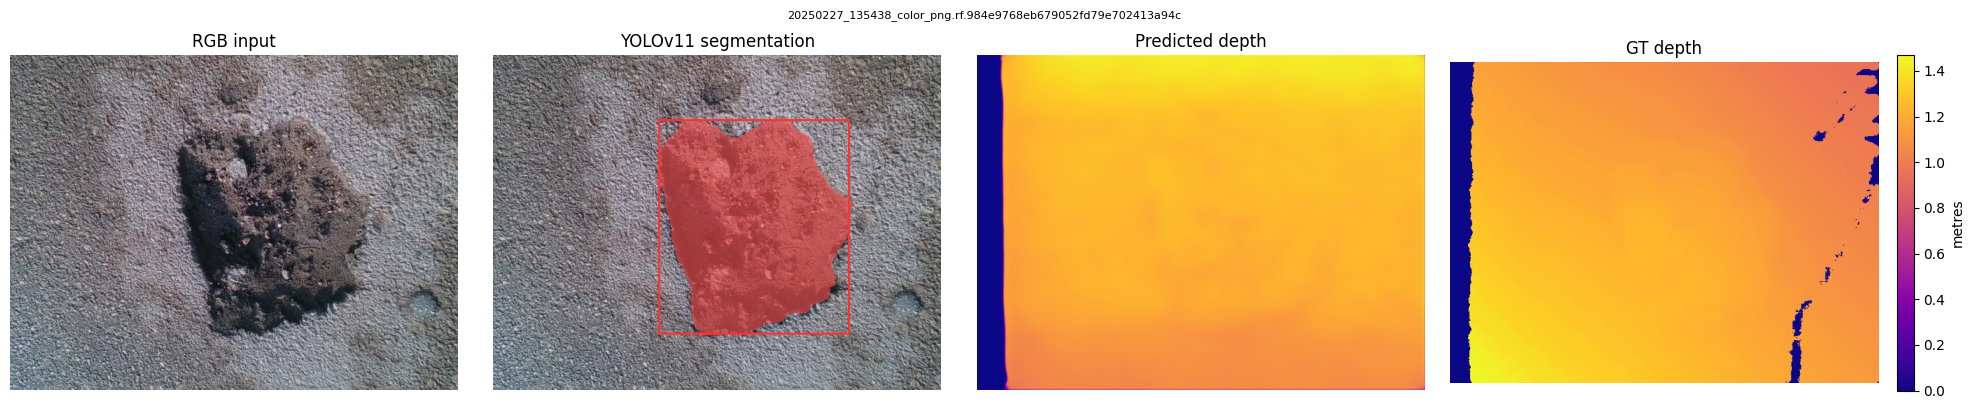


Sample 2: 20250227_135652_color_png.rf.c3e37f97ea7f729ce0c04d4272dbab7d.jpg
Saved: /content/vis_1.png


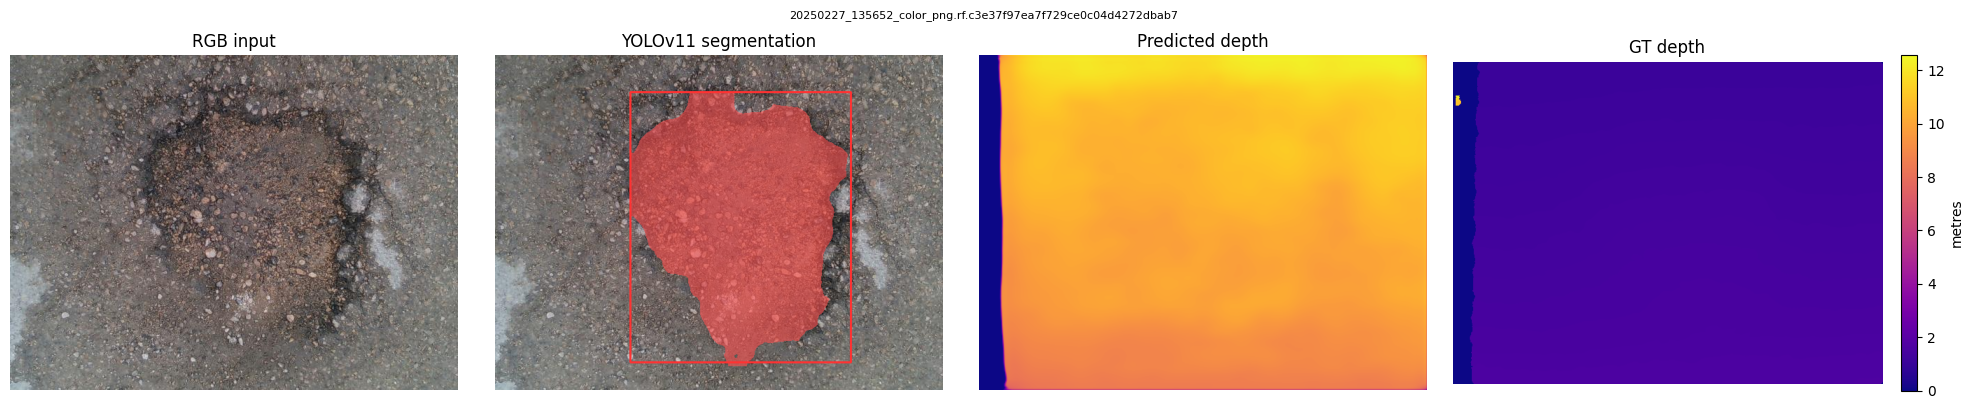


Sample 3: 20250227_140407_color_png.rf.c4475270462eea5151c53046692d9239.jpg
Saved: /content/vis_2.png


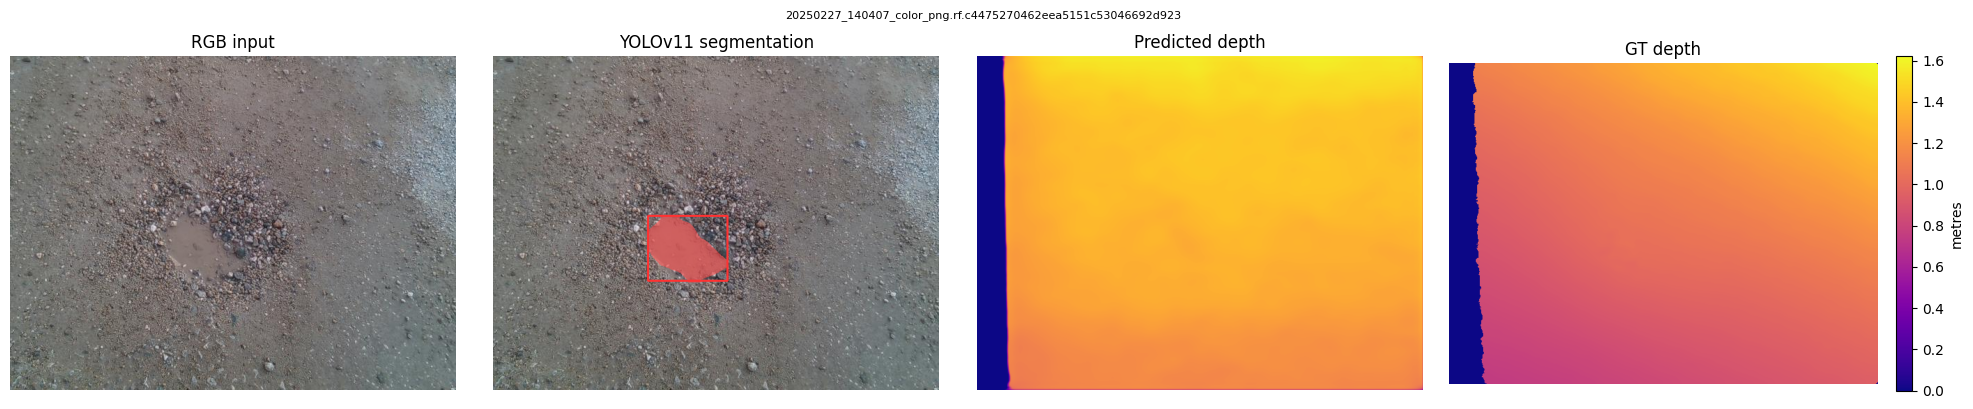


Sample 4: 20250227_140905_color_png.rf.2d12799a85d2760abf8ee447509e62de.jpg
Saved: /content/vis_3.png


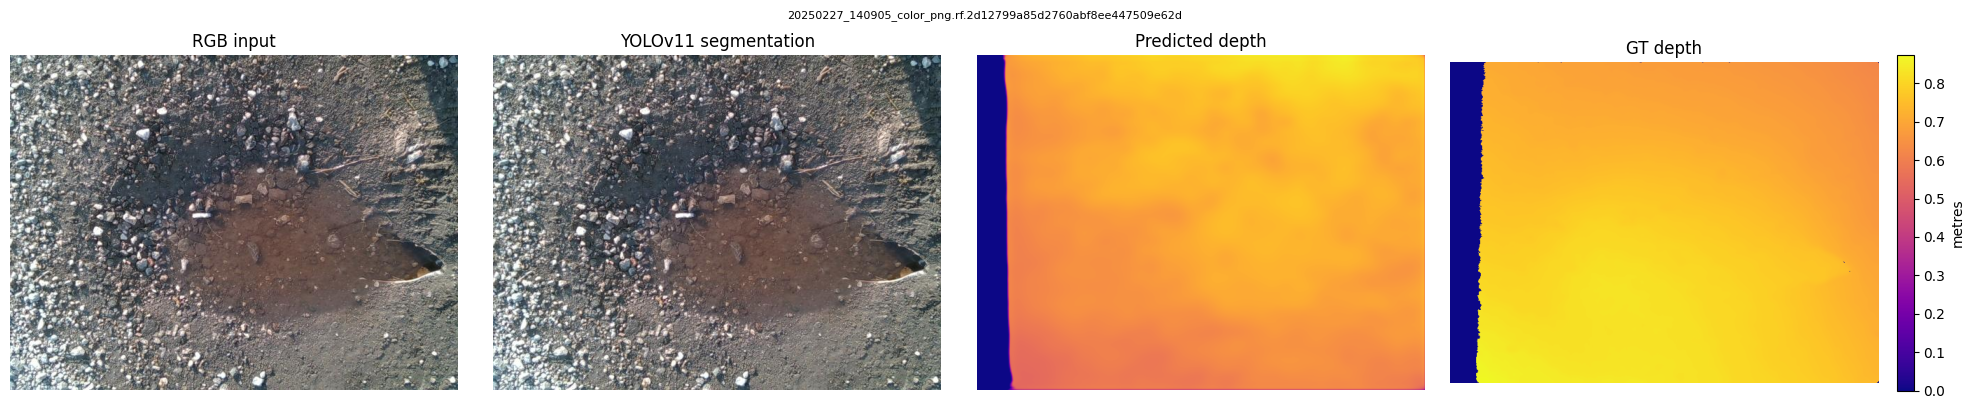


Sample 5: 20250227_141050_color_png.rf.4682f3a780dcc539b18b35c4c819567f.jpg
Saved: /content/vis_4.png


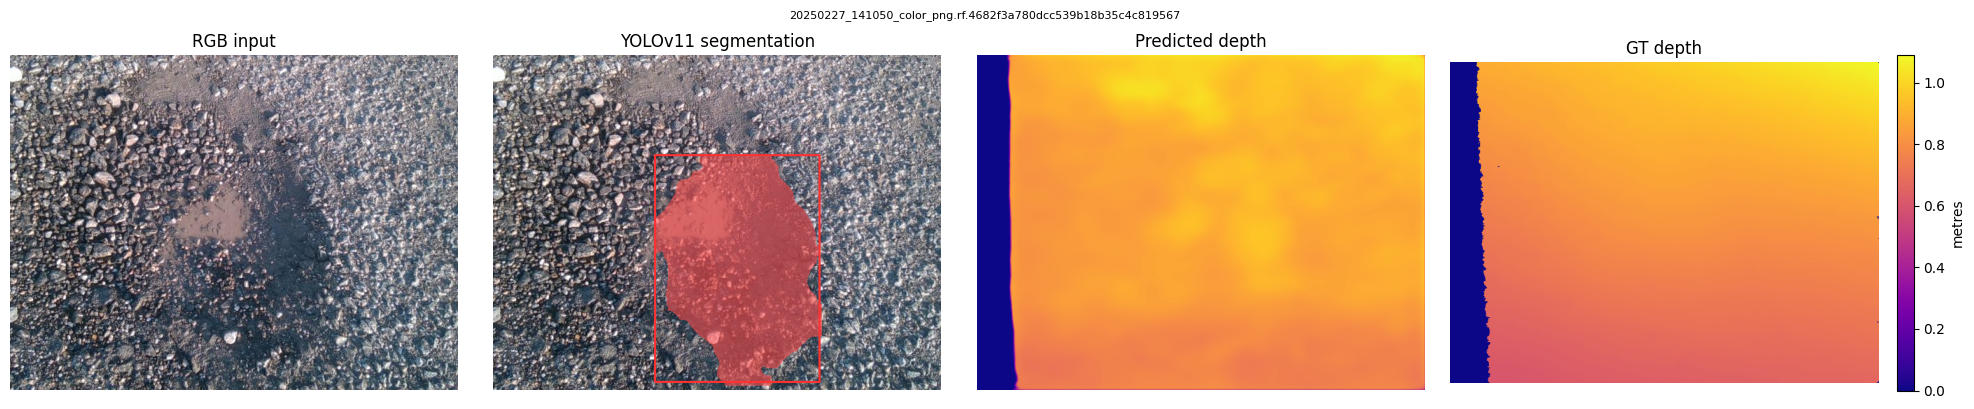

In [11]:
# ============================================================
# CELL 7 (FIXED) — Qualitative visualization
# ============================================================
import cv2, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms

# depth_transform — define here in case it's not in scope
depth_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
])

def visualize_sample(rgb_path, depth_path, yolo_model, depth_model,
                     depth_transform, save_path=None):
    """
    rgb_path   : Path to the RGB image
    depth_path : Path to the matching .npy GT depth file (or None)
    """
    rgb_bgr = cv2.imread(str(rgb_path))
    if rgb_bgr is None:
        print(f"Could not read: {rgb_path}")
        return
    rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)
    H, W = rgb.shape[:2]

    # ── YOLO segmentation ──────────────────────────────────
    yolo_pred = yolo_model.predict(str(rgb_path), conf=0.25, verbose=False)[0]
    overlay   = rgb.copy().astype(np.float32)
    if yolo_pred.masks is not None:
        for mask in yolo_pred.masks.data.cpu().numpy():
            m = cv2.resize(mask, (W, H))
            overlay[m > 0.5] = (overlay[m > 0.5] * 0.4
                                 + np.array([255, 80, 80]) * 0.6)
    overlay = overlay.clip(0, 255).astype(np.uint8)
    for box in yolo_pred.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 50, 50), 2)

    # ── Depth prediction ───────────────────────────────────
    inp = depth_transform(rgb).unsqueeze(0).cuda()
    with torch.no_grad():
        pred_d = depth_model(inp)
        if isinstance(pred_d, (list, tuple)): pred_d = pred_d[-1]
        if pred_d.ndim == 4: pred_d = pred_d.squeeze(1)
        pred_d = pred_d.squeeze().cpu().float().numpy()
    pred_d_r = cv2.resize(pred_d, (W, H), interpolation=cv2.INTER_LINEAR)

    # ── GT depth (.npy — not PNG) ──────────────────────────
    if depth_path is not None and Path(depth_path).exists():
        gt_d = np.load(str(depth_path)).astype(np.float32)
        if gt_d.max() > 100:          # mm → metres
            gt_d = gt_d / 1000.0
        gt_d = cv2.resize(gt_d, (W, H), interpolation=cv2.INTER_NEAREST)
    else:
        gt_d = np.zeros((H, W), dtype=np.float32)

    # ── Plot ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    axes[0].imshow(rgb);                              axes[0].set_title("RGB input")
    axes[1].imshow(overlay);                          axes[1].set_title("YOLOv11 segmentation")
    axes[2].imshow(pred_d_r, cmap="plasma");          axes[2].set_title("Predicted depth")
    im = axes[3].imshow(gt_d, cmap="plasma");         axes[3].set_title("GT depth")
    plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04, label="metres")
    for ax in axes: ax.axis("off")
    plt.suptitle(Path(rgb_path).stem[:60], fontsize=8, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# ── Use the pairs list from Cell 6 ────────────────────────
# 'pairs' is the list of (rgb_path, depth_path) tuples built in Cell 6
VISUALIZE_N = 5   # how many samples to show

print(f"Visualizing {VISUALIZE_N} samples from {len(pairs)} matched pairs...")
for idx, (rgb_p, dep_p) in enumerate(pairs[:VISUALIZE_N]):
    print(f"\nSample {idx+1}: {rgb_p.name}")
    visualize_sample(
        rgb_path       = rgb_p,
        depth_path     = dep_p,
        yolo_model     = yolo_model,
        depth_model    = depth_model,
        depth_transform= depth_transform,
        save_path      = f"/content/vis_{idx}.png"
    )

In [12]:
# ============================================================
# CELL 8 (FIXED) — Full summary report
# ============================================================
from datetime import datetime
import numpy as np

# ── Guard: check all required variables exist ──────────────
def safe_mean(d, key):
    vals = d.get(key, [])
    return np.mean(vals) if vals else float('nan')

print("=" * 54)
print("    MODEL VALIDATION REPORT")
print(f"    Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 54)

# ── YOLOv11 block ─────────────────────────────────────────
print("\n── YOLOv11 Segmentation ──────────────────────────────")
try:
    seg_p  = results.seg.mp
    seg_r  = results.seg.mr
    seg_f1 = 2 * seg_p * seg_r / (seg_p + seg_r + 1e-9)

    print(f"  mAP50        : {results.seg.map50:.4f}")
    print(f"  mAP50-95     : {results.seg.map:.4f}")
    print(f"  Precision    : {seg_p:.4f}")
    print(f"  Recall       : {seg_r:.4f}")
    print(f"  F1 Score     : {seg_f1:.4f}")
    print(f"  [Box] mAP50  : {results.box.map50:.4f}")
    print(f"  [Box] mAP50-95: {results.box.map:.4f}")

    # Mask IoU — from Cell 5 (may not exist if that cell was skipped)
    try:
        print(f"  Mean Mask IoU: {np.mean(all_mask_ious):.4f}  (n={len(all_mask_ious)})")
    except NameError:
        print("  Mean Mask IoU: (run Cell 5 to compute)")

except NameError:
    print("  ⚠️  'results' not defined — run Cell 4 (YOLO validation) first.")

# ── DepthAnythingV2 block ─────────────────────────────────
print("\n── DepthAnythingV2 (vits, fine-tuned on PothRGBD) ───")
try:
    depth_metric_order = ["AbsRel", "SqRel", "RMSE", "logRMSE", "SILog",
                          "d1", "d2", "d3"]
    direction = {"AbsRel":"↓","SqRel":"↓","RMSE":"↓","logRMSE":"↓",
                 "SILog":"↓","d1":"↑","d2":"↑","d3":"↑"}
    n_samples = len(next(iter(all_metrics.values()), []))
    print(f"  Evaluated on {n_samples} image pairs")
    for k in depth_metric_order:
        val = safe_mean(all_metrics, k)
        arr = direction.get(k, "")
        print(f"  {k:<10}: {val:.4f}  {arr}")
except NameError:
    print("  ⚠️  'all_metrics' not defined — run Cell 6 (depth eval) first.")

# ── Output files ─────────────────────────────────────────
print("\n── Saved outputs ────────────────────────────────────")
import os
saved = [f"/content/{f}" for f in os.listdir("/content")
         if f.startswith("vis_") or f.endswith(".png")]
for s in sorted(saved):
    print(f"  {s}")
if not saved:
    print("  (no visualizations saved yet — run Cell 7)")

print("\n" + "=" * 54)

    MODEL VALIDATION REPORT
    Generated: 2026-05-01 11:27

── YOLOv11 Segmentation ──────────────────────────────
  mAP50        : 0.9834
  mAP50-95     : 0.6990
  Precision    : 0.9809
  Recall       : 0.9675
  F1 Score     : 0.9742
  [Box] mAP50  : 0.9834
  [Box] mAP50-95: 0.7369
  Mean Mask IoU: (run Cell 5 to compute)

── DepthAnythingV2 (vits, fine-tuned on PothRGBD) ───
  Evaluated on 1000 image pairs
  AbsRel    : 0.0505  ↓
  SqRel     : 0.0210  ↓
  RMSE      : 0.1064  ↓
  logRMSE   : 0.0656  ↓
  SILog     : 6.5100  ↓
  d1        : 0.9705  ↑
  d2        : 0.9928  ↑
  d3        : 0.9970  ↑

── Saved outputs ────────────────────────────────────
  /content/vis_0.png
  /content/vis_1.png
  /content/vis_2.png
  /content/vis_3.png
  /content/vis_4.png

